# Spatial Predator-Prey: Spiral Waves of Life and Death

Population ecology has a famous pair of equations - the **Lotka-Volterra** model - in which prey multiply, predators eat prey, and the two chase each other in endless boom-and-bust cycles. Those equations are *continuous* and *well-mixed*: they assume every animal can meet every other. Real ecosystems are not well-mixed. They have **space**, and space changes everything.

This notebook puts the ecology on a grid. Each cell is **grass**, a **rabbit**, or a **fox**, and the rules are entirely local:

- a **rabbit** grazing next to **grass** turns that grass into a new rabbit,
- a **fox** next to a **rabbit** turns that rabbit into a new fox,
- a **fox** surrounded by grass has no prey, starves, and the ground returns to grass.

That is a cycle - grass beaten by rabbits, rabbits beaten by foxes, foxes beaten by bare grass - and on a grid it does something a mean-field line chart cannot show: it organizes itself into rotating **spiral waves** that support long-lived coexistence. Take the space away and the cycle becomes much easier to break. This lesson is the bridge from discrete cellular rules (Module 3) to continuous population models in mathematical biology.


## 1. The Cyclic Rule

Number the states `grass = 0`, `rabbit = 1`, `fox = 2`. Each state is consumed by the next one in the cycle:

> grass -> rabbit -> fox -> grass

So the species that "beats" state `s` is its **successor** `(s + 1) % 3`. A cell flips to that successor when enough of its neighbors already are it: three or more grazing rabbits convert a grass cell, three or more foxes convert a rabbit, and three or more patches of bare grass starve a fox. One simple local rule, applied everywhere at once.


**Imports and setup.** Arrays, plotting, animation, and the three-state colormap.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib import animation
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

GRASS, RABBIT, FOX = 0, 1, 2
CMAP = ListedColormap(["#4d9e5a", "#d9cfa3", "#ef6a4a"])  # grass, rabbit, fox
LEGEND = [Patch(color="#4d9e5a", label="grass"),
          Patch(color="#d9cfa3", label="rabbit"),
          Patch(color="#ef6a4a", label="fox")]

# Moore neighborhood (8 cells)
OFFSETS = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]


**One synchronous step.** Each cell flips to its successor `(s+1)%3` when at least `threshold` Moore-neighbors are that successor; toroidal edges keep the geometry uniform.


In [2]:
def step(grid, threshold=3):
    successor = (grid + 1) % 3
    count = np.zeros(grid.shape, dtype=int)
    for dr, dc in OFFSETS:
        count += (np.roll(np.roll(grid, dr, axis=0), dc, axis=1) == successor)
    return np.where(count >= threshold, successor, grid)


def fractions(grid):
    n = grid.size
    return np.array([(grid == s).sum() / n for s in (GRASS, RABBIT, FOX)])


def run(size=120, generations=160, seed=0, threshold=3, well_mixed=False):
    rng = np.random.default_rng(seed)
    grid = rng.integers(3, size=(size, size))
    history = []
    for _ in range(generations + 1):
        history.append({"grid": grid.copy(), "fractions": fractions(grid)})
        if well_mixed:
            flat = grid.ravel().copy()
            rng.shuffle(flat)               # destroy spatial structure: well-mixed
            grid = flat.reshape(grid.shape)
        grid = step(grid, threshold)
    return history


history = run()
print("start grass/rabbit/fox =", history[0]["fractions"].round(3))
print("end   grass/rabbit/fox =", history[-1]["fractions"].round(3))


start grass/rabbit/fox = [0.333 0.333 0.335]
end   grass/rabbit/fox = [0.353 0.303 0.343]


## 2. Watch the Spirals Form

From a random start, local invasions quickly organize into rotating spiral waves: a front of rabbits chasing grass, a front of foxes chasing the rabbits, and grass regrowing behind the foxes. No spiral is designed; each emerges from the single local rule.


**Draw a board.** Green is grass, tan is rabbits, orange is foxes.


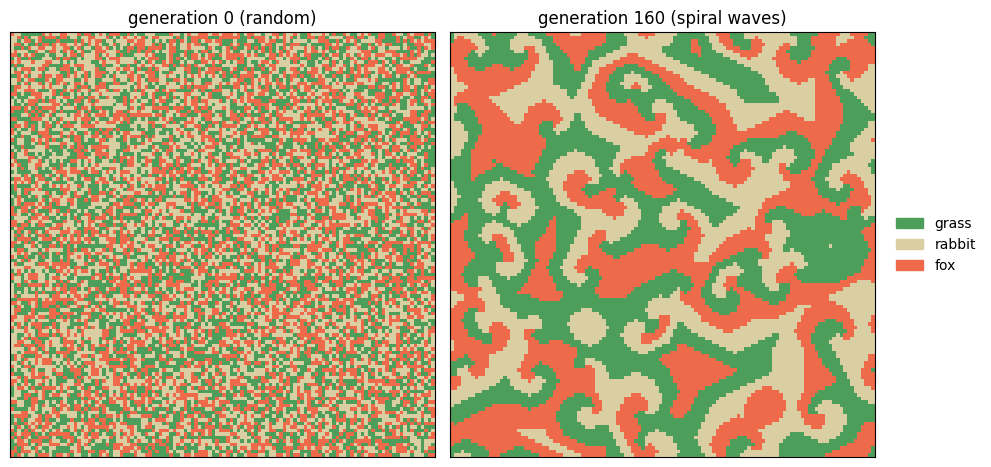

In [3]:
def draw(grid, ax=None, title=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(grid, cmap=CMAP, vmin=0, vmax=2, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title)
    return ax


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
draw(history[0]["grid"], axes[0], "generation 0 (random)")
draw(history[-1]["grid"], axes[-1], f"generation {len(history) - 1} (spiral waves)")
axes[1].legend(handles=LEGEND, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()


**Population curve.** On a line chart the three species cycle and stay balanced near a third each - none wins, none dies.


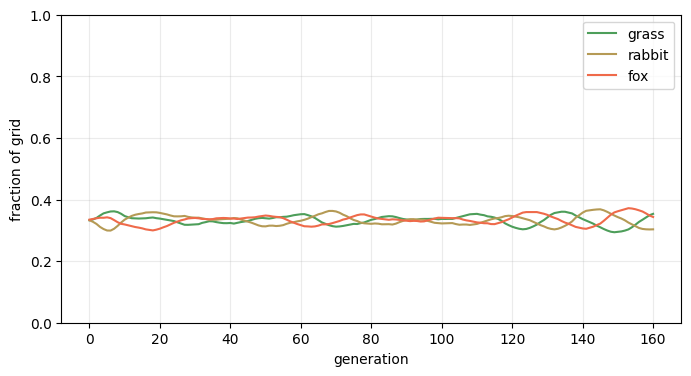

In [4]:
def plot_populations(history):
    fr = np.array([h["fractions"] for h in history])
    fig, ax = plt.subplots(figsize=(8, 4))
    for s, name, color in [(GRASS, "grass", "#4d9e5a"), (RABBIT, "rabbit", "#b59a55"), (FOX, "fox", "#ef6a4a")]:
        ax.plot(fr[:, s], label=name, color=color)
    ax.set_xlabel("generation"); ax.set_ylabel("fraction of grid")
    ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.25)
    plt.show()


plot_populations(history)


**Animation.** Replay the grid and watch the spiral arms rotate.


In [5]:
def animate(history, stride=2):
    frames = history[::stride]
    fig, ax = plt.subplots(figsize=(5.4, 5))

    def update(i):
        ax.clear()
        fr = frames[i]["fractions"]
        draw(frames[i]["grid"], ax,
             f"grass {fr[0]:.2f}  rabbit {fr[1]:.2f}  fox {fr[2]:.2f}")

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=140)
    plt.close(fig)
    return HTML(anim.to_jshtml())


animate(history)


## 3. Failure Mode: Remove the Space

The spirals are not decoration - they are the *reason* all three species survive. A fox in a spiral arm always has rabbits just ahead and grass recovering behind, so the chase never runs out of room.

Take the space away. Below we **shuffle the whole grid every generation**, which makes the system **well-mixed**: every cell's neighbors are now random, the kind of assumption behind mean-field population equations. The spiral structure cannot form, the populations swing wildly, and one species drifts to extinction - after which the cycle is broken and a single species takes the entire grid.


**Well-mixed run.** Shuffle each generation; on a smaller grid a species goes extinct quickly.


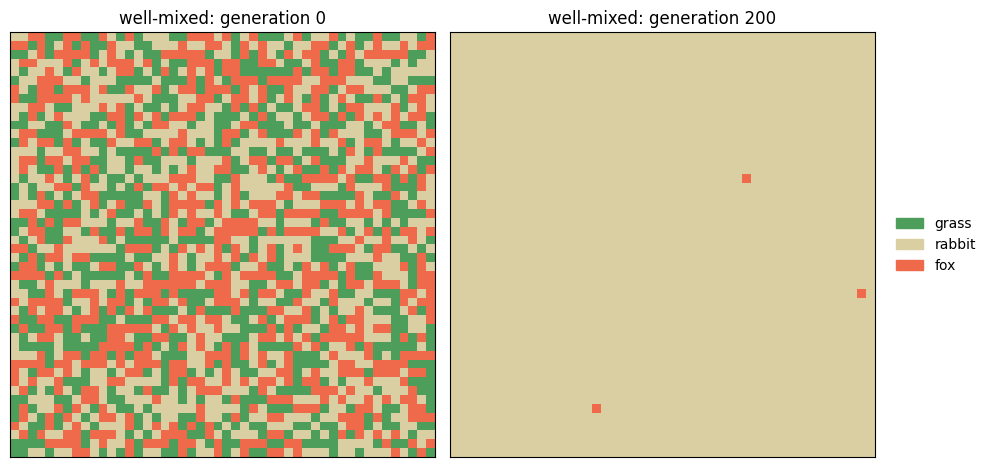

well-mixed end grass/rabbit/fox = [0.    0.999 0.001]
species still alive: 1 of 3  (spatial keeps all 3; well-mixed collapses)


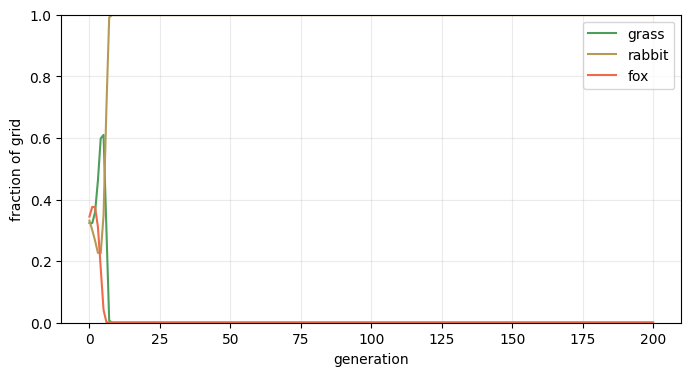

In [6]:
well_mixed = run(size=48, generations=200, seed=1, well_mixed=True)
end = well_mixed[-1]["fractions"]
survivors = int((end > 0.01).sum())   # a sub-1% remnant is an extinction in progress

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
draw(well_mixed[0]["grid"], axes[0], "well-mixed: generation 0")
draw(well_mixed[-1]["grid"], axes[1], f"well-mixed: generation {len(well_mixed) - 1}")
axes[1].legend(handles=LEGEND, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout(); plt.show()

print("well-mixed end grass/rabbit/fox =", end.round(3))
print("species still alive:", survivors, "of 3  (spatial keeps all 3; well-mixed collapses)")
plot_populations(well_mixed)


## 4. The Bridge to Differential Equations

Why does well-mixing kill coexistence? Average the local rule over the whole grid and the discrete model becomes a set of **differential equations** - the continuous, well-mixed limit. With fractions `g`, `r`, `f` for grass, rabbits, foxes, the same cycle reads:

```
dg/dt = g (f - r)      grass spreads where foxes died, retreats where rabbits graze
dr/dt = r (g - f)      rabbits grow on grass, fall where foxes hunt
df/dt = f (r - g)      foxes grow on rabbits, starve where only grass remains
```

These are a cyclic relative of the Lotka-Volterra equations. In the ideal deterministic model they have **neutrally stable cycles**: the populations loop in closed boom-bust orbits around the balance point. But the orbits are only *neutrally* stable, so finite-population noise can push the loop outward until it touches zero and a species is lost. Space is what damps that drift; the well-mixed approximation has nothing to hold the cycle in.


**Integrate the mean-field model.** A 4th-order Runge-Kutta step keeps the closed orbit clean.


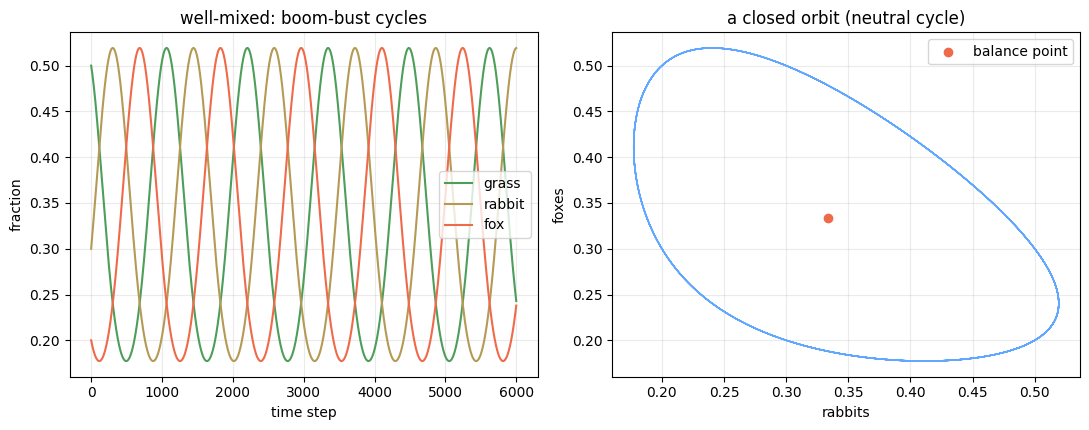

In [7]:
def mean_field(steps=6000, dt=0.01, start=(0.5, 0.3, 0.2)):
    def deriv(state):
        g, r, f = state
        return np.array([g * (f - r), r * (g - f), f * (r - g)])

    state = np.array(start, dtype=float)
    traj = [state.copy()]
    for _ in range(steps):
        k1 = deriv(state)
        k2 = deriv(state + 0.5 * dt * k1)
        k3 = deriv(state + 0.5 * dt * k2)
        k4 = deriv(state + dt * k3)
        state = state + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        traj.append(state.copy())
    return np.array(traj)


traj = mean_field()
fig, (axt, axp) = plt.subplots(1, 2, figsize=(11, 4.4))
for s, name, color in [(0, "grass", "#4d9e5a"), (1, "rabbit", "#b59a55"), (2, "fox", "#ef6a4a")]:
    axt.plot(traj[:, s], label=name, color=color)
axt.set_xlabel("time step"); axt.set_ylabel("fraction"); axt.set_title("well-mixed: boom-bust cycles")
axt.legend(); axt.grid(alpha=0.25)

axp.plot(traj[:, 1], traj[:, 2], color="#62a7ff", lw=1)
axp.scatter([1 / 3], [1 / 3], color="#ef6a4a", zorder=5, label="balance point")
axp.set_xlabel("rabbits"); axp.set_ylabel("foxes"); axp.set_title("a closed orbit (neutral cycle)")
axp.legend(); axp.grid(alpha=0.25)
plt.tight_layout(); plt.show()


## 5. Mini-Challenge

Try one:

1. Lower the `threshold` to 1 or 2. The grid still coexists, but the motion freezes into near-static patches - what happened to the rotating waves, and why does a higher threshold restore them?
2. Shrink the well-mixed grid further (`size=24`). How does extinction time change as the system gets smaller, and what does that say about real, finite populations?
3. Break the cycle: make foxes unable to die (never flip fox back to grass). Which species takes over, and why does removing one arrow collapse the whole rotation?
4. Seed the grid as three solid blocks instead of random noise. Do spirals still form, and where do they nucleate?
5. From the mean-field plot, estimate the period of one boom-bust cycle, then compare it with the spiral rotation period you can read off the animation.


**Invariant check.** Every cell is exactly one species, the three fractions sum to one, and a cell only ever changes into its cyclic successor.


In [8]:
g0 = history[5]["grid"]
g1 = step(g0)
print("every cell is grass/rabbit/fox:", bool(np.isin(g1, [GRASS, RABBIT, FOX]).all()))
print("fractions sum to one:", round(float(fractions(g1).sum()), 6))

changed = g1 != g0
legal = (g1[changed] == ((g0[changed] + 1) % 3)).all()
print("every change is into the cyclic successor (s -> s+1):", bool(legal))


every cell is grass/rabbit/fox: True
fractions sum to one: 1.0
every change is into the cyclic successor (s -> s+1): True


## Visual Trace + Rigor Studio

**Problem frame.** Model an ecosystem of grass, rabbits, and foxes with only local rules, and watch whether the populations coexist, oscillate, or collapse.

**Interactive animation target.** Animate the grid (green grass, tan rabbits, orange foxes) as spiral waves rotate, beside the population-fraction curve, with controls for grid size, the invasion threshold, and whether the grid is well-mixed.

**Correctness handle.** The update is local and synchronous: each cell becomes its cyclic successor `(s+1)%3` only when at least `threshold` neighbors already are it, so every cell is always exactly one species and the three fractions sum to one.

**Complexity handle.** Each generation is `O(cells * neighbors)` work, vectorized over the grid; a run of `T` generations is `O(T * cells)`.

**Failure mode to test.** Shuffle the grid every generation (well-mixed). The spiral structure cannot form, the cycle drifts outward, and a species goes extinct - so spatial structure, not the rule alone, is what sustains coexistence.

**Studio task.** Find the threshold that produces rotating spirals rather than frozen patches, then shrink the well-mixed grid and measure how extinction time falls as the population gets smaller.

**Transfer.** This is the spatial counterpart to mean-field population models in ecology and epidemiology, and its lesson echoes the Spatial Prisoner's Dilemma: local structure in space sustains coexistence (here) and cooperation (there) that well-mixed dynamics can destroy. The rotating fronts are the same excitable-medium waves that Turing patterns formalize in the next lesson.


## Sources and Further Reading

- Alfred J. Lotka, *Elements of Physical Biology* (1925), and Vito Volterra, [Fluctuations in the Abundance of a Species considered Mathematically](https://doi.org/10.1038/118558a0) (1926) - early predator-prey equations.
- Tobias Reichenbach, Mauro Mobilia, and Erwin Frey, [Mobility promotes and jeopardizes biodiversity in rock-paper-scissors games](https://doi.org/10.1038/nature06095), *Nature* 448, 1046-1049 (2007) - spiral waves and how mixing destroys coexistence.
- Robert M. May and Warren J. Leonard, [Nonlinear aspects of competition between three species](https://doi.org/10.1137/0129022), *SIAM J. Applied Math* 29, 243-253 (1975) - the cyclic three-species model.

This is a compact teaching version. Real spatial ecology also models movement, age and energy, stochastic birth and death rates, and habitats that are not a uniform torus.
